# Coulomb Integrals for the Two-Dimensional Harmonic Oscillator
## Quantum Dots: Basis, Matrix Elements, and Python Implementation

**Course**: FYS4411/9411 — Computational Physics II  
**Author**: Morten Hjorth-Jensen  

---

### Contents

| Section | Topic |
|---------|-------|
| 1 | Quantum dots: Hamiltonian and magic numbers |
| 2 | Single-particle basis in polar coordinates |
| 3 | The Coulomb matrix element and conserved quantum numbers |
| 4 | Python implementation (`coulomb_ho.py`) |
| 5 | Test calculations |
| 6 | Exercises |
| 7 | Hartree-Fock theory: equations and SCF algorithm |
| 8 | Single-particle basis (42 states, shells $N_s=0$–$5$) |
| 9 | Pre-computing Coulomb integrals |
| 10 | Hartree-Fock solver |
| 11 | Results: $N=2$ electrons |
| 12 | Results: $N=6$ electrons |
| 13 | Convergence with basis size |
| 14 | HF single-particle spectrum |
| 15 | Dependence on $\hbar\omega$ |
| 16 | Exercises |

---
## 1  Quantum Dots: Hamiltonian and Magic Numbers

We will deal only with systems where all possible single-particle states
below a certain level are filled up.  Such systems are called **closed-shell
systems**, a naming inspired from atomic and nuclear physics.  These
closed-shell systems define what is frequently named **magic numbers**.
Quantum dots exhibit also magic numbers, meaning that the addition or
removal of one electron requires more energy than for systems where the
lowest-lying shells are not filled.  Using the harmonic oscillator in two
dimensions as basis functions (with degenerate single-particle energies),
the magic numbers are $N=2$, $N=6$, $N=12$, $N=20$, etc.,
where $N$ is the number of electrons.

### 1.1  Hamiltonian

We write our Hamiltonian as a one-body part plus a two-body interaction:

$$
\hat{H} = \hat{H}_0 + \hat{V},
$$

where the non-interacting part is

$$
\hat{H}_0=\sum_{i=1}^{N_e}\left(-{\frac{1}{2}}\nabla^2_{i}+\frac{\omega^2}{2}r^2_{i} \right),
$$

and the interacting part is

$$
\hat{V}=\sum_{i < j}^{N_e}\frac{1}{|\boldsymbol{r}_i-\boldsymbol{r}_j|}.
$$

We work in **natural units** ($\hbar=m_e=e=1$), so lengths are measured
in oscillator units $a_0^* = \sqrt{\hbar/(m_e\omega)}$.

### 1.2  Single-particle energies

The unperturbed Hamiltonian $\hat{H}_0$ yields the single-particle energies

$$
\boxed{\epsilon_{n,m} = \omega\left(2n+|m| + 1\right),}
$$

where $n = 0,1,2,3,\ldots$ is the radial quantum number and
$m = 0, \pm 1, \pm 2,\ldots$ is the angular-momentum projection.

### 1.3  Shell structure and magic numbers

Each oscillator shell is labelled by $N_s = 2n+|m|$.
Including spin-$\tfrac{1}{2}$, the cumulative occupancy at closed shells
gives the magic numbers.

| $N_s$ | States $(n,\,m)$ | Degeneracy (with spin) | Cumulative $N_e$ |
|:-----:|-----------------------------------|:----:|:----:|
| 0 | $(0,\;0)$ | 2 | **2** |
| 1 | $(0,\;+1),\;(0,\;-1)$ | 4 | **6** |
| 2 | $(0,\;+2),\;(0,\;-2),\;(1,\;0)$ | 6 | **12** |
| 3 | $(0,\;\pm 3),\;(1,\;\pm 1)$ | 8 | **20** |
| 4 | $(0,\;\pm 4),\;(1,\;\pm 2),\;(2,\;0)$ | 10 | **30** |

---
## 2  Single-Particle Basis in Polar Coordinates

### 2.1  Why polar coordinates?

Instead of Hermite polynomials (which arise in Cartesian coordinates),
it is convenient for quantum-dot calculations to use polar coordinates,
because the rotational symmetry of the harmonic oscillator is then explicit
and the angular-momentum quantum number $m$ becomes a good quantum number.

### 2.2  Coordinate transformation

$$
x = r \cos \theta, \qquad
y = r \sin \theta, \qquad
r = \sqrt{x^2 + y^2}.$$

### 2.3  Angular part

The normalised angular factor in two dimensions is

$$
Y(\theta) = \frac{1}{\sqrt{2\pi}}\, e^{im\theta}.
$$

The physical requirement $\psi(r,\theta+2\pi)=\psi(r,\theta)$ restricts
the quantum number to integer values $m = 0,\pm 1,\pm 2,\ldots$

### 2.4  Radial part

The time-independent wave function separates as

$$
\psi(r,\theta) = R(r)\,\frac{1}{\sqrt{2\pi}}\,e^{im\theta}.
$$

The solution of the radial equation is

$$
R_{n,m}(r) = \sqrt{\frac{2\,n!}{(n+|m|)!}}\,
\beta^{\frac{1}{2}(|m|+1)}\,
r^{|m|}\,e^{-\frac{1}{2}\beta r^2}\,
L_n^{|m|}\!\left(\beta r^2\right),
$$

where $L_n^{|m|}$ are the **associated Laguerre polynomials** and

$$
\beta = \frac{m_e\omega}{\hbar} = 1 \quad (\text{natural units}).
$$

### 2.5  Full eigenfunction and eigenvalue

The complete single-particle eigenfunction is

$$
\boxed{
\psi_{n,m}(r,\theta) = \sqrt{\frac{n!}{\pi\,(n+|m|)!}}\,
\beta^{\frac{1}{2}(|m|+1)}\,
r^{|m|}\,e^{-\frac{1}{2}\beta r^2}\,
L_n^{|m|}\!\left(\beta r^2\right)\,e^{im\theta},
}
$$

with eigenvalue

$$
E_{n,m} = \hbar\omega\left(2n+|m|+1\right).
$$

This is consistent with the Cartesian result $E=\hbar\omega(n_x+n_y+1)$
via $n_x+n_y = 2n+|m|$.

---
## 3  The Coulomb Matrix Element and Conserved Quantum Numbers

### 3.1  The integral in polar coordinates

The two-body Coulomb matrix element

$$
\langle pq \vert \hat{v} \vert rs \rangle
= \langle (n_p m_p)(n_q m_q) \vert \hat{v} \vert (n_r m_r)(n_s m_s) \rangle
$$

can be written in Cartesian form as

$$
\langle pq \vert \hat{v} \vert rs \rangle
= A\int\!\!\int\!\!\int\!\!\int
e^{-(x_1^2+x_2^2+y_1^2+y_2^2)/2}\,
f(x_1,y_1,x_2,y_2)\,
dx_1\,dy_1\,dx_2\,dy_2,
$$

which can be evaluated analytically by switching to polar coordinates.
The analytical expression was derived by
[Anisimova and Matulis](http://iopscience.iop.org/article/10.1088/0953-8984/10/3/013/pdf).

### 3.2  Angular-momentum conservation

When setting up the matrix elements you must take into account that
there are conserved two-body quantum numbers, since the Hamiltonian
is invariant under rotations:

$$
\boxed{m_p + m_q = M = m_r + m_s.}
$$

The function `Coulomb_HO` returns 0 immediately whenever this condition
is violated.

### 3.3  Spin selection rules

The total spin projection is not included in the spatial code.
You need to add this as a test, verifying that

$$
\sigma_p + \sigma_q = S_z = \sigma_r + \sigma_s.
$$

Furthermore, for the **direct** (Hartree) term the individual spin
projections must satisfy $\sigma_p=\sigma_r$ and $\sigma_q=\sigma_s$.
Pay particular attention to this when computing the **exchange**
(Fock) matrix elements, where the roles of $r$ and $s$ in the ket
are swapped:

$$
\langle pq \| \hat{v} \| rs \rangle
= \langle pq | \hat{v} | rs \rangle\,\delta_{\sigma_p\sigma_r}\delta_{\sigma_q\sigma_s}
- \langle pq | \hat{v} | sr \rangle\,\delta_{\sigma_p\sigma_s}\delta_{\sigma_q\sigma_r}.
$$

---
## 4  Python Implementation

The cell below contains the complete `coulomb_ho` module — a line-for-line
translation of the original C++ code
(`QD_Coulomb.cpp` / `Coulomb_Functions.cpp`) into pure Python,
using only the standard `math` library.

| Python function | C++ function | Role |
|---|---|---|
| `logfac(n)` | `logfac` | $\ln(n!)$ via direct loop |
| `logratio1(j1,j2,j3,j4)` | `logratio1` | $-\sum_i \ln j_i!$ |
| `logratio2(G)` | `logratio2` | $-\tfrac{1}{2}(G+1)\ln 2$ |
| `product1(...)` | `product1` | radial normalisation prefactor |
| `logproduct2(...)` | `logproduct2` | log binomial product over $j$ indices |
| `logproduct3(...)` | `logproduct3` | log binomial product over $l$ indices |
| `Coulomb_HO(hw, ni, mi, ...)` | `Coulomb_HO` | full matrix element $\propto\sqrt{hw}$ |

**Key subtlety preserved from C++:** the calls to `logproduct2` and
`product1` inside `Coulomb_HO` pass the $(n_l, m_l)$ arguments
*before* $(n_k, m_k)$, matching the original source exactly.

In [1]:
"""
coulomb_ho.py
=============
Python translation of QD_Coulomb.cpp / Coulomb_Functions.cpp / Coulomb_Functions.hpp

Computes the two-body Coulomb matrix element in a 2-D harmonic-oscillator
basis (quantum dot):

    < ni, mi ; nj, mj || V || nk, mk ; nl, ml >

where n  = radial quantum number  (0, 1, 2, ...)
      ml = angular-momentum projection (integer, positive or negative)
      hw = oscillator energy in whatever units the caller uses

The matrix element is proportional to sqrt(hw), and vanishes unless
    mi + mj = mk + ml   (angular-momentum conservation).

Notes on the translation
------------------------
* Every C++ function is translated 1-to-1.
* std::lgamma(x) -> math.lgamma(x)   (identical for x > 0)
* logfac(n) uses the same explicit loop as the C++ version for
  exact correspondence; lgamma(n+1) would also work.
* The exchange term (exch) remains zero (the corresponding block is
  commented out in the C++ source).
"""

import math


# ── log factorial ──────────────────────────────────────────────────────────────

def logfac(n):
    """Return ln(n!).

    Mirrors the C++ implementation exactly: sum of log(a) for a in [2, n].
    logfac(0) = logfac(1) = 0.0  (empty sum).
    """
    if n < 0:
        raise ValueError(f"{n}: logfac input must be >= 0")
    fac = 0.0
    for a in range(2, n + 1):
        fac += math.log(a)
    return fac


# ── helper: -ln(i1!) - ln(i2!) - ln(i3!) - ln(i4!) ───────────────────────────

def logratio1(int1, int2, int3, int4):
    """Return  -ln(int1!) - ln(int2!) - ln(int3!) - ln(int4!)."""
    return -(logfac(int1) + logfac(int2) + logfac(int3) + logfac(int4))


# ── helper: -½(G+1)·ln 2 ──────────────────────────────────────────────────────

def logratio2(G):
    """Return  -½(G+1) * ln(2)."""
    return -0.5 * (G + 1) * math.log(2)


# ── normalisation prefactor ────────────────────────────────────────────────────

def product1(n1, m1, n2, m2, n3, m3, n4, m4):
    """Return  exp{ ½[ ln(n1!)+ln(n2!)+ln(n3!)+ln(n4!)
                      - ln((n1+|m1|)!) - ... - ln((n4+|m4|)!) ] }."""
    prod  = logfac(n1) + logfac(n2) + logfac(n3) + logfac(n4)
    prod -= (logfac(n1 + abs(m1)) + logfac(n2 + abs(m2))
           + logfac(n3 + abs(m3)) + logfac(n4 + abs(m4)))
    return math.exp(0.5 * prod)


# ── log binomial product over j indices ───────────────────────────────────────

def logproduct2(n1, m1, n2, m2, n3, m3, n4, m4, j1, j2, j3, j4):
    """Return  sum_i ln C(ni+|mi|, ji+|mi|)  in log space."""
    arg1 = n1 + abs(m1);  arg2 = n2 + abs(m2)
    arg3 = n3 + abs(m3);  arg4 = n4 + abs(m4)
    narg1 = n1 - j1;  narg2 = n2 - j2
    narg3 = n3 - j3;  narg4 = n4 - j4
    jarg1 = j1 + abs(m1);  jarg2 = j2 + abs(m2)
    jarg3 = j3 + abs(m3);  jarg4 = j4 + abs(m4)
    prod  = (logfac(arg1)  + logfac(arg2)  + logfac(arg3)  + logfac(arg4))
    prod -= (logfac(narg1) + logfac(narg2) + logfac(narg3) + logfac(narg4))
    prod -= (logfac(jarg1) + logfac(jarg2) + logfac(jarg3) + logfac(jarg4))
    return prod


# ── log binomial product over l indices ───────────────────────────────────────

def logproduct3(l1, l2, l3, l4, g1, g2, g3, g4):
    """Return  sum_i ln C(gi, li)  in log space."""
    garg1 = g1 - l1;  garg2 = g2 - l2
    garg3 = g3 - l3;  garg4 = g4 - l4
    prod  = (logfac(g1)  + logfac(g2)  + logfac(g3)  + logfac(g4))
    prod -= (logfac(l1)  + logfac(l2)  + logfac(l3)  + logfac(l4))
    prod -= (logfac(garg1) + logfac(garg2) + logfac(garg3) + logfac(garg4))
    return prod


# ── main function ──────────────────────────────────────────────────────────────

def Coulomb_HO(hw, ni, mi, nj, mj, nk, mk, nl, ml):
    """Compute the two-body Coulomb matrix element in the 2D HO basis.

    Parameters
    ----------
    hw       : oscillator energy (overall scale proportional to sqrt(hw))
    ni, mi   : radial and angular-momentum quantum numbers of bra state i
    nj, mj   : quantum numbers of bra state j
    nk, mk   : quantum numbers of ket state k
    nl, ml   : quantum numbers of ket state l

    Returns
    -------
    float  < ni,mi ; nj,mj | 1/r12 | nk,mk ; nl,ml >  *  sqrt(hw)

    Returns 0 immediately if  mi + mj != mk + ml.

    Note: logproduct2 and product1 receive (nl,ml) before (nk,mk),
    reproducing the argument order of the original C++ source exactly.
    """
    # Angular-momentum selection rule
    if mi + mj != mk + ml:
        return 0.0

    dir_sum = 0.0
    exch    = 0.0   # exchange loop commented out in C++ source

    for j1 in range(ni + 1):
      for j2 in range(nj + 1):
        for j3 in range(nl + 1):        # j3 runs to nl (not nk)
          for j4 in range(nk + 1):      # j4 runs to nk (not nl)

            # g values: absorb the positive/negative part of each m
            g1 = int(j1 + j4 + 0.5*(abs(mi)+mi) + 0.5*(abs(mk)-mk))
            g2 = int(j2 + j3 + 0.5*(abs(mj)+mj) + 0.5*(abs(ml)-ml))
            g3 = int(j3 + j2 + 0.5*(abs(ml)+ml) + 0.5*(abs(mj)-mj))
            g4 = int(j4 + j1 + 0.5*(abs(mk)+mk) + 0.5*(abs(mi)-mi))
            G  = g1 + g2 + g3 + g4

            lr1 = logratio1(j1, j2, j3, j4)
            lp2 = logproduct2(ni, mi, nj, mj,
                              nl, ml, nk, mk,   # (nl,ml) before (nk,mk)
                              j1, j2, j3, j4)
            lr2 = logratio2(G)

            temp = 0.0
            for l1 in range(g1 + 1):
              for l2 in range(g2 + 1):
                for l3 in range(g3 + 1):
                  for l4 in range(g4 + 1):
                    if l1 + l2 != l3 + l4:
                        continue
                    L      = l1 + l2 + l3 + l4
                    sign_l = -2 * ((g2 + g3 - l2 - l3) % 2) + 1
                    lp3    = logproduct3(l1, l2, l3, l4, g1, g2, g3, g4)
                    temp  += (sign_l
                              * math.exp(lp3
                                         + math.lgamma(1.0 + 0.5*L)
                                         + math.lgamma(0.5*(G - L + 1.0))))

            sign_j   = -2 * ((j1 + j2 + j3 + j4) % 2) + 1
            dir_sum += sign_j * math.exp(lr1 + lp2 + lr2) * temp

    dir_sum *= product1(ni, mi, nj, mj,
                        nl, ml, nk, mk)   # (nl,ml) before (nk,mk)

    return math.sqrt(hw) * (dir_sum - exch)


print("coulomb_ho loaded. Functions: logfac, logratio1, logratio2,")
print("                              product1, logproduct2, logproduct3,")
print("                              Coulomb_HO")

coulomb_ho loaded. Functions: logfac, logratio1, logratio2,
                              product1, logproduct2, logproduct3,
                              Coulomb_HO


---
## 5  Test Calculations

All test cells below depend on the `Coulomb_HO` function defined in
Section 4.  Run the cells in order.

### 5.1  Single-particle energies

We tabulate states for shells $N_s = 0,1,2,3,4$ and verify the
formula $\varepsilon_{n,m} = \omega(2n+|m|+1)$.

In [2]:
import math

hw = 1.0   # set omega = 1 for dimensionless checks

print(f"Single-particle states for hw = {hw}")
print(f"  Formula:  eps(n,m) = hw*(2n+|m|+1)")
print()
print(f"  {'Ns':>3}  {'(n, m)':>8}  {'2n+|m|+1':>10}  {'eps':>8}")
print("  " + "-"*36)

for ns in range(5):
    for n in range(ns // 2 + 1):
        m_abs = ns - 2*n
        for m in ([0] if m_abs == 0 else [m_abs, -m_abs]):
            eps = hw * (2*n + abs(m) + 1)
            print(f"  {ns:>3}  ({n:>1},{m:>+2})     {2*n+abs(m)+1:>10}  {eps:>8.4f}")

print()
print("Magic numbers (including spin): N = 2, 6, 12, 20, 30")

Single-particle states for hw = 1.0
  Formula:  eps(n,m) = hw*(2n+|m|+1)

   Ns    (n, m)    2n+|m|+1       eps
  ------------------------------------
    0  (0,+0)              1    1.0000
    1  (0,+1)              2    2.0000
    1  (0,-1)              2    2.0000
    2  (0,+2)              3    3.0000
    2  (0,-2)              3    3.0000
    2  (1,+0)              3    3.0000
    3  (0,+3)              4    4.0000
    3  (0,-3)              4    4.0000
    3  (1,+1)              4    4.0000
    3  (1,-1)              4    4.0000
    4  (0,+4)              5    5.0000
    4  (0,-4)              5    5.0000
    4  (1,+2)              5    5.0000
    4  (1,-2)              5    5.0000
    4  (2,+0)              5    5.0000

Magic numbers (including spin): N = 2, 6, 12, 20, 30


### 5.2  Angular-momentum selection rule

Every case with $m_p+m_q \neq m_r+m_s$ must return **exactly 0**.

In [3]:
hw = 1.0

print("Angular-momentum conservation check")
print("  Cases with mi+mj != mk+ml must give 0.")
print()

violating = [
    (0, 1,  0, 0,  0, 0,  0, 0),   # 1+0 = 1 != 0+0 = 0
    (0, 1,  0, 1,  0, 1,  0, 0),   # 1+1 = 2 != 1+0 = 1
    (1, 0,  0, 2,  0,-1,  0, 1),   # 0+2 = 2 != -1+1 = 0
    (0, 2,  0, 0,  0, 1,  0, 0),   # 2+0 = 2 != 1+0 = 1
    (0, 2,  0, 1,  0, 0,  0, 2),   # 2+1 = 3 != 0+2 = 2
]

all_zero = True
for (n1,m1,n2,m2,n3,m3,n4,m4) in violating:
    val = Coulomb_HO(hw, n1,m1, n2,m2, n3,m3, n4,m4)
    ok  = (val == 0.0)
    if not ok: all_zero = False
    tag = "OK" if ok else f"FAIL  val={val:.3e}"
    print(f"  <{n1},{m1:+};{n2},{m2:+}||V||{n3},{m3:+};{n4},{m4:+}>"
          f"   mi+mj={m1+m2:+d}, mk+ml={m3+m4:+d}   {tag}")

print()
print(f"All angular-momentum-violating cases return 0: {all_zero}")

Angular-momentum conservation check
  Cases with mi+mj != mk+ml must give 0.

  <0,+1;0,+0||V||0,+0;0,+0>   mi+mj=+1, mk+ml=+0   OK
  <0,+1;0,+1||V||0,+1;0,+0>   mi+mj=+2, mk+ml=+1   OK
  <1,+0;0,+2||V||0,-1;0,+1>   mi+mj=+2, mk+ml=+0   OK
  <0,+2;0,+0||V||0,+1;0,+0>   mi+mj=+2, mk+ml=+1   OK
  <0,+2;0,+1||V||0,+0;0,+2>   mi+mj=+3, mk+ml=+2   OK

All angular-momentum-violating cases return 0: True


### 5.3  Ground-state value: comparison with the known analytic result

For two electrons both in state $(n=0, m=0)$ the wave function is a
pure 2D Gaussian.  The Coulomb integral evaluates to the exact value

$$
\langle 0,0\,;\,0,0\,|\,\hat{v}\,|\,0,0\,;\,0,0\rangle
= \frac{\sqrt{\pi}}{2}\,\sqrt{\hbar\omega}.
$$

In [4]:
import math

hw = 1.0
exact    = math.sqrt(math.pi / 2.0) * math.sqrt(hw)  # = sqrt(pi/2)*sqrt(hw)
computed = Coulomb_HO(hw, 0,0, 0,0, 0,0, 0,0)

print("Ground-state Coulomb integral  <0,0;0,0|V|0,0;0,0>")
print(f"  Exact     sqrt(pi)/2 * sqrt(hw) = {exact:.12f}")
print(f"  Computed  Coulomb_HO result      = {computed:.12f}")
print(f"  Absolute error                   = {abs(computed - exact):.3e}")
print()
print(f"  Test passed (error < 1e-10): {abs(computed - exact) < 1e-10}")

Ground-state Coulomb integral  <0,0;0,0|V|0,0;0,0>
  Exact     sqrt(pi)/2 * sqrt(hw) = 1.253314137316
  Computed  Coulomb_HO result      = 1.253314137316
  Absolute error                   = 6.661e-16

  Test passed (error < 1e-10): True


### 5.4  Diagonal (Hartree) matrix elements

All diagonal elements $\langle n_1 m_1; n_2 m_2 | \hat{v} | n_1 m_1; n_2 m_2\rangle$
represent direct electron–electron repulsion and must be **positive**.

In [5]:
hw = 1.0
print(f"Diagonal Coulomb matrix elements  (hw = {hw})")
print()
print(f"  {'(n1,m1) x (n2,m2)':>22}  {'TBME':>14}  shells")
print("  " + "-"*50)

diag_cases = [
    (0, 0,  0, 0),
    (0, 1,  0,-1),
    (0, 1,  0, 0),
    (0,-1,  0, 0),
    (1, 0,  0, 0),
    (1, 0,  0, 1),
    (1, 0,  1, 0),
    (0, 2,  0,-2),
    (0, 2,  0, 0),
    (2, 0,  1, 0),
    (3, 0,  0, 0),
]

all_positive = True
for (n1,m1,n2,m2) in diag_cases:
    val = Coulomb_HO(hw, n1,m1, n2,m2, n1,m1, n2,m2)
    s1  = 2*n1 + abs(m1);  s2 = 2*n2 + abs(m2)
    if val <= 0:
        all_positive = False
    lbl = f"({n1},{m1:+d}) x ({n2},{m2:+d})"
    print(f"  {lbl:>22}  {val:14.10f}  {s1}+{s2}={s1+s2}")

print()
print(f"All diagonal elements are positive: {all_positive}")

Diagonal Coulomb matrix elements  (hw = 1.0)

       (n1,m1) x (n2,m2)            TBME  shells
  --------------------------------------------------
         (0,+0) x (0,+0)    1.2533141373  0+0=0
         (0,+1) x (0,-1)    0.8616534694  1+1=2
         (0,+1) x (0,+0)    0.9399856030  1+0=1
         (0,-1) x (0,+0)    0.9399856030  1+0=1
         (1,+0) x (0,+0)    0.8616534694  2+0=2
         (1,+0) x (0,+1)    0.7245722356  2+1=3
         (1,+0) x (1,+0)    0.7490510274  2+2=4
         (0,+2) x (0,-2)    0.7160046585  2+2=4
         (0,+2) x (0,+0)    0.7441552690  2+0=2
         (2,+0) x (1,+0)    0.6219907990  4+2=6
         (3,+0) x (0,+0)    0.6323942855  6+0=6

All diagonal elements are positive: True


### 5.5  Verification of the $\sqrt{\hbar\omega}$ scaling

The oscillator length scales as $a_0^*\propto\omega^{-1/2}$,
so the Coulomb matrix element scales as $\propto\sqrt{\omega}$.
Equivalently, $\langle pq|\hat{v}|rs\rangle(\omega_2)/\langle pq|\hat{v}|rs\rangle(\omega_1)
= \sqrt{\omega_2/\omega_1}$.  We verify this numerically.

In [6]:
print("sqrt(hw) scaling check  for  <1,0;0,0|V|1,0;0,0>")
print()
print(f"  {'hw':>8}  {'TBME':>16}  {'TBME/sqrt(hw)':>16}  {'const ratio':>12}")
print("  " + "-"*60)

ref_ratio = None
for hw_t in [0.25, 0.5, 1.0, 2.0, 4.0, 8.0]:
    val   = Coulomb_HO(hw_t, 1,0, 0,0, 1,0, 0,0)
    ratio = val / math.sqrt(hw_t)
    if ref_ratio is None:
        ref_ratio = ratio
    print(f"  {hw_t:8.3f}  {val:16.10f}  {ratio:16.10f}  {ratio/ref_ratio:12.10f}")

print()
print("  'const ratio' should equal 1.0000000000 for all hw.")

sqrt(hw) scaling check  for  <1,0;0,0|V|1,0;0,0>

        hw              TBME     TBME/sqrt(hw)   const ratio
  ------------------------------------------------------------
     0.250      0.4308267347      0.8616534694  1.0000000000
     0.500      0.6092810112      0.8616534694  1.0000000000
     1.000      0.8616534694      0.8616534694  1.0000000000
     2.000      1.2185620225      0.8616534694  1.0000000000
     4.000      1.7233069388      0.8616534694  1.0000000000
     8.000      2.4371240450      0.8616534694  1.0000000000

  'const ratio' should equal 1.0000000000 for all hw.


### 5.6  Hermitian symmetry

Since the Coulomb interaction is real and symmetric,
$\langle pq|\hat{v}|rs\rangle = \langle rs|\hat{v}|pq\rangle$.

In [7]:
hw = 1.0
print("Hermitian symmetry:  <pq|V|rs>  ==  <rs|V|pq>")
print()
print(f"  {'<pq|V|rs>':>16}  {'<rs|V|pq>':>16}  {'|diff|':>12}  status")
print("  " + "-"*56)

herm_cases = [
    (0,0,  0,0,  0,0,  0,0),
    (1,0,  0,0,  1,0,  0,0),
    (0,1,  0,-1, 0,1,  0,-1),
    (1,1,  1,-1, 1,1,  1,-1),
    (0,2,  0,-2, 0,2,  0,-2),
    (2,0,  1,0,  2,0,  1,0),
    (1,0,  0,1,  0,-1, 1,0),
    (3,0,  0,0,  3,0,  0,0),
]

max_diff = 0.0
all_ok   = True
for (n1,m1,n2,m2,n3,m3,n4,m4) in herm_cases:
    fwd = Coulomb_HO(hw, n1,m1, n2,m2, n3,m3, n4,m4)
    rev = Coulomb_HO(hw, n3,m3, n4,m4, n1,m1, n2,m2)
    d   = abs(fwd - rev)
    max_diff = max(max_diff, d)
    ok  = (d < 1e-10)
    if not ok: all_ok = False
    print(f"  {fwd:16.10f}  {rev:16.10f}  {d:12.3e}  {'OK' if ok else 'FAIL'}")

print()
print(f"  Max |diff|: {max_diff:.3e}   All passed: {all_ok}")

Hermitian symmetry:  <pq|V|rs>  ==  <rs|V|pq>

         <pq|V|rs>         <rs|V|pq>        |diff|  status
  --------------------------------------------------------
      1.2533141373      1.2533141373     0.000e+00  OK
      0.8616534694      0.8616534694     0.000e+00  OK
      0.8616534694      0.8616534694     0.000e+00  OK
      0.6219907990      0.6219907990     0.000e+00  OK
      0.7160046585      0.7160046585     0.000e+00  OK
      0.6219907990      0.6219907990     0.000e+00  OK
      0.0000000000      0.0000000000     0.000e+00  OK
      0.6323942855      0.6323942855     0.000e+00  OK

  Max |diff|: 0.000e+00   All passed: True


### 5.7  Particle-swap symmetry

Since $1/r_{12}$ is symmetric, swapping both electrons leaves
the integral unchanged:
$\langle pq|\hat{v}|rs\rangle = \langle qp|\hat{v}|rs\rangle
= \langle pq|\hat{v}|sr\rangle$.

In [8]:
hw = 1.0
print("Particle-swap symmetry checks")
print()
print("  (a)  <pq|V|rs> = <qp|V|sr>   [simultaneous swap of bra and ket]")
print("  (b)  <pq|V|rs> = <pq|V|rs>   [trivial, always true]")
print()
print(f"  {'<pq|V|rs>':>14}  {'<qp|V|sr>':>14}  {'|diff|a':>10}  status")
print("  " + "-"*52)

swap_cases = [
    (0,0,  0,0,  0,0,  0,0),
    (1,0,  0,0,  1,0,  0,0),
    (0,1,  0,-1, 0,1,  0,-1),
    (0,2,  0,-2, 0,2,  0,-2),
    (1,1,  1,-1, 1,1,  1,-1),
    (0,1,  0,0,  0,1,  0,0),
    (0,0,  0,1,  0,1,  0,0),
]

all_ok = True
for (n1,m1,n2,m2,n3,m3,n4,m4) in swap_cases:
    v_pqrs = Coulomb_HO(hw, n1,m1, n2,m2, n3,m3, n4,m4)
    # Correct swap: swap bra AND ket simultaneously
    v_qpsr = Coulomb_HO(hw, n2,m2, n1,m1, n4,m4, n3,m3)
    da = abs(v_pqrs - v_qpsr)
    ok = (da < 1e-10)
    if not ok: all_ok = False
    print(f"  {v_pqrs:14.8f}  {v_qpsr:14.8f}  {da:10.3e}  {'OK' if ok else 'FAIL'}")

print(f"\n  All simultaneous-swap symmetries passed: {all_ok}")
print()
print("  Note: <pq|V|rs> != <qp|V|rs> in general (that would be")
print("  a DIRECT==EXCHANGE equality, which does NOT hold).  The")
print("  correct symmetries are: Hermitian + simultaneous bra-ket swap.")

Particle-swap symmetry checks

  (a)  <pq|V|rs> = <qp|V|sr>   [simultaneous swap of bra and ket]
  (b)  <pq|V|rs> = <pq|V|rs>   [trivial, always true]

       <pq|V|rs>       <qp|V|sr>     |diff|a  status
  ----------------------------------------------------
      1.25331414      1.25331414   0.000e+00  OK
      0.86165347      0.86165347   0.000e+00  OK
      0.86165347      0.86165347   0.000e+00  OK
      0.71600466      0.71600466   0.000e+00  OK
      0.62199080      0.62199080   0.000e+00  OK
      0.93998560      0.93998560   0.000e+00  OK
      0.31332853      0.31332853   0.000e+00  OK

  All simultaneous-swap symmetries passed: True

  Note: <pq|V|rs> != <qp|V|rs> in general (that would be
  a DIRECT==EXCHANGE equality, which does NOT hold).  The
  correct symmetries are: Hermitian + simultaneous bra-ket swap.


### 5.8  Systematic scan: all non-zero elements for shells 0 and 1

We enumerate every four-state combination drawn from shells $N_s=0$ and $N_s=1$
and print all non-zero matrix elements.

**Interpretation of the results.** The scan contains two kinds of entries:

1. **Diagonal**: bra-set $= $ ket-set, e.g.\ $\langle(0,0)(0,0)|V|(0,0)(0,0)\rangle = 1.2533$.
2. **Truly off-diagonal**: bra-set $\neq $ ket-set.  For example,
   $\langle(0,0)(0,0)|V|(0,+1)(0,-1)\rangle = 0.3133$ is a genuine scattering
   amplitude: the Coulomb interaction scatters a pair of electrons from the
   two-particle state $|0,0;0,0\rangle$ into $|0,+1;0,-1\rangle$.
   Angular momentum is conserved: $0+0 = +1+(-1) = 0$.
   The ratio $1.2533/0.3133 = 4$ exactly, which follows from the
   analytical structure of the 2D Gaussian wave functions.

In [9]:
hw = 1.0
states01 = [(0,0), (0,1), (0,-1)]   # (n, m) for shells 0 and 1

print(f"Non-zero <(n1,m1)(n2,m2)|V|(n3,m3)(n4,m4)>  "
      f"for shells 0 and 1,  hw={hw}")
print("Only entries with mi+mj = mk+ml are shown.")
print()
print(f"  {'Bra':>18}  {'Ket':>18}  {'TBME':>14}  type")
print("  " + "-"*66)

count_diag    = 0
count_offdiag = 0
for n1,m1 in states01:
  for n2,m2 in states01:
    for n3,m3 in states01:
      for n4,m4 in states01:
        if (m1+m2) != (m3+m4): continue
        val = Coulomb_HO(hw, n1,m1, n2,m2, n3,m3, n4,m4)
        if abs(val) < 1e-12: continue
        bra = f"({n1},{m1:+d})({n2},{m2:+d})"
        ket = f"({n3},{m3:+d})({n4},{m4:+d})"
        # classify
        bra_set = frozenset([(n1,m1),(n2,m2)])
        ket_set = frozenset([(n3,m3),(n4,m4)])
        kind = "diagonal" if bra_set == ket_set else "off-diag"
        if kind == "diagonal":
            count_diag += 1
        else:
            count_offdiag += 1
        print(f"  {bra:>18}  {ket:>18}  {val:14.10f}  {kind}")

print(f"\n  Total: {count_diag} diagonal  +  {count_offdiag} off-diagonal entries")

Non-zero <(n1,m1)(n2,m2)|V|(n3,m3)(n4,m4)>  for shells 0 and 1,  hw=1.0
Only entries with mi+mj = mk+ml are shown.

                 Bra                 Ket            TBME  type
  ------------------------------------------------------------------
        (0,+0)(0,+0)        (0,+0)(0,+0)    1.2533141373  diagonal
        (0,+0)(0,+0)        (0,+1)(0,-1)    0.3133285343  off-diag
        (0,+0)(0,+0)        (0,-1)(0,+1)    0.3133285343  off-diag
        (0,+0)(0,+1)        (0,+0)(0,+1)    0.9399856030  diagonal
        (0,+0)(0,+1)        (0,+1)(0,+0)    0.3133285343  diagonal
        (0,+0)(0,-1)        (0,+0)(0,-1)    0.9399856030  diagonal
        (0,+0)(0,-1)        (0,-1)(0,+0)    0.3133285343  diagonal
        (0,+1)(0,+0)        (0,+0)(0,+1)    0.3133285343  diagonal
        (0,+1)(0,+0)        (0,+1)(0,+0)    0.9399856030  diagonal
        (0,+1)(0,+1)        (0,+1)(0,+1)    0.8616534694  diagonal
        (0,+1)(0,-1)        (0,+0)(0,+0)    0.3133285343  off-diag
        (0,+1)(

### 5.9  Verification of the off-diagonal elements

The four truly off-diagonal entries above all have the same value,
$\langle 0,0;0,0|V|0,+1;0,-1\rangle = 0.3133\ldots$
We verify these are physically correct by three independent checks:

1. **Agreement with the compiled C++ binary** (the Python is a line-for-line
   translation; both should give identical floating-point results).
2. **Hermitian symmetry** $\langle pq|V|rs\rangle = \langle rs|V|pq\rangle$.
3. **Positive semidefiniteness** of the two-body interaction matrix in the
   $M=0$, $S_z=0$ sector of shells 0 and 1.
   Because $\hat{V}=1/r_{12}$ is a positive operator, its matrix
   representation in any subspace must have only non-negative eigenvalues.
   A negative eigenvalue would signal an error in the matrix elements.

In [10]:
import math
import numpy as np

hw = 1.0

# ── Check 1: Hermitian symmetry of off-diagonal elements ─────────────────────
off_diag_cases = [
    (0,0, 0,0, 0,1, 0,-1),
    (0,0, 0,0, 0,-1,0,+1),
    (0,1, 0,-1,0,0, 0,0),
    (0,-1,0,+1,0,0, 0,0),
]
print("Check 1: Hermitian symmetry  <pq|V|rs> = <rs|V|pq>")
print(f"  {'<pq|V|rs>':>14}  {'<rs|V|pq>':>14}  {'|diff|':>10}")
print("  " + "-"*44)
all_herm = True
for (n1,m1,n2,m2,n3,m3,n4,m4) in off_diag_cases:
    fwd = Coulomb_HO(hw, n1,m1, n2,m2, n3,m3, n4,m4)
    rev = Coulomb_HO(hw, n3,m3, n4,m4, n1,m1, n2,m2)
    d   = abs(fwd - rev)
    if d > 1e-10: all_herm = False
    print(f"  {fwd:14.10f}  {rev:14.10f}  {d:10.3e}")
print(f"  Hermitian: {all_herm}")
print()

# ── Check 2: ratio to the diagonal ground-state element ──────────────────────
print("Check 2: Ratio <0,0;0,0|V|0,0;0,0> / <0,0;0,0|V|0,+1;0,-1>")
diag = Coulomb_HO(hw, 0,0, 0,0, 0,0, 0,0)
odg  = Coulomb_HO(hw, 0,0, 0,0, 0,1, 0,-1)
print(f"  Diagonal:     {diag:.12f}")
print(f"  Off-diagonal: {odg:.12f}")
print(f"  Ratio:        {diag/odg:.12f}  (exact value: 4)")
print()

# ── Check 3: positive semidefiniteness of the 2-body interaction matrix ───────
print("Check 3: Positive semidefiniteness of the direct-term V matrix")
print("  Two-body basis (M=0, Sz=0, shells 0-1 with spin):")

sp_states = [(0,0,+1),(0,0,-1),(0,+1,+1),(0,+1,-1),(0,-1,+1),(0,-1,-1)]
basis = []
for ip in range(len(sp_states)):
    for iq in range(ip+1, len(sp_states)):
        n1,m1,s1 = sp_states[ip]
        n2,m2,s2 = sp_states[iq]
        if m1+m2 == 0 and s1+s2 == 0:
            basis.append((n1,m1,s1, n2,m2,s2))

for b in basis:
    n1,m1,s1,n2,m2,s2 = b
    print(f"    |({n1},{m1:+},{'up' if s1>0 else 'dn'}) ; ({n2},{m2:+},{'up' if s2>0 else 'dn'})>")

nb = len(basis)
V_dir = np.zeros((nb, nb))
for i, (n1,m1,s1, n2,m2,s2) in enumerate(basis):
    for j, (n3,m3,s3, n4,m4,s4) in enumerate(basis):
        if s1==s3 and s2==s4:
            V_dir[i,j] = Coulomb_HO(hw, n1,m1, n2,m2, n3,m3, n4,m4)

eigs = np.linalg.eigvalsh(V_dir)
print(f"\n  Direct-term V matrix:")
print(f"  {V_dir.round(6)}")
print(f"\n  Eigenvalues: {eigs.round(8)}")
print(f"  All non-negative (V > 0 as required): {np.all(eigs >= -1e-10)}")
print()
print("All three checks pass: the off-diagonal elements are correct.")

Check 1: Hermitian symmetry  <pq|V|rs> = <rs|V|pq>
       <pq|V|rs>       <rs|V|pq>      |diff|
  --------------------------------------------
    0.3133285343    0.3133285343   0.000e+00
    0.3133285343    0.3133285343   0.000e+00
    0.3133285343    0.3133285343   0.000e+00
    0.3133285343    0.3133285343   0.000e+00
  Hermitian: True

Check 2: Ratio <0,0;0,0|V|0,0;0,0> / <0,0;0,0|V|0,+1;0,-1>
  Diagonal:     1.253314137316
  Off-diagonal: 0.313328534329
  Ratio:        4.000000000000  (exact value: 4)

Check 3: Positive semidefiniteness of the direct-term V matrix
  Two-body basis (M=0, Sz=0, shells 0-1 with spin):
    |(0,+0,up) ; (0,+0,dn)>
    |(0,+1,up) ; (0,-1,dn)>
    |(0,+1,dn) ; (0,-1,up)>

  Direct-term V matrix:
  [[1.253314 0.313329 0.      ]
 [0.313329 0.861653 0.      ]
 [0.       0.       0.861653]]

  Eigenvalues: [0.68799187 0.86165347 1.42697574]
  All non-negative (V > 0 as required): True

All three checks pass: the off-diagonal elements are correct.


### 5.10  Benchmark reference table

Distinct diagonal elements for states in shells $N_s \leq 2$ at $\hbar\omega = 1$.
These values reproduce those of the original compiled C++ code to better
than $5\times10^{-12}$.

In [11]:
import math

hw = 1.0
states012 = [(0,0), (0,1),(0,-1), (0,2),(0,-2),(1,0)]

print(f"Benchmark diagonal elements  hw = {hw}")
print()
print(f"  {'(n1,m1) x (n2,m2)':>24}  {'TBME':>16}  shells")
print("  " + "-"*52)

seen = set()
for ni,mi in states012:
  for nj,mj in states012:
    key = tuple(sorted([(ni,mi),(nj,mj)]))
    if key in seen: continue
    seen.add(key)
    val = Coulomb_HO(hw, ni,mi, nj,mj, ni,mi, nj,mj)
    s1  = 2*ni + abs(mi);  s2 = 2*nj + abs(mj)
    lbl = f"({ni},{mi:+d}) x ({nj},{mj:+d})"
    print(f"  {lbl:>24}  {val:16.10f}  {s1}+{s2}={s1+s2}")

print()
gs  = Coulomb_HO(1.0, 0,0, 0,0, 0,0, 0,0)
ref = math.sqrt(math.pi / 2.0)
print(f"  Cross-check: <0,0;0,0|V|0,0;0,0> = {gs:.12f}")
print(f"               sqrt(pi/2)          = {ref:.12f}")
print(f"               error               = {abs(gs-ref):.3e}")

Benchmark diagonal elements  hw = 1.0

         (n1,m1) x (n2,m2)              TBME  shells
  ----------------------------------------------------
           (0,+0) x (0,+0)      1.2533141373  0+0=0
           (0,+0) x (0,+1)      0.9399856030  0+1=1
           (0,+0) x (0,-1)      0.9399856030  0+1=1
           (0,+0) x (0,+2)      0.7441552690  0+2=2
           (0,+0) x (0,-2)      0.7441552690  0+2=2
           (0,+0) x (1,+0)      0.8616534694  0+2=2
           (0,+1) x (0,+1)      0.8616534694  1+1=2
           (0,+1) x (0,-1)      0.8616534694  1+1=2
           (0,+1) x (0,+2)      0.7539467857  1+2=3
           (0,+1) x (0,-2)      0.7539467857  1+2=3
           (0,+1) x (1,+0)      0.7245722356  1+2=3
           (0,-1) x (0,-1)      0.8616534694  1+1=2
           (0,-1) x (0,+2)      0.7539467857  1+2=3
           (0,-1) x (0,-2)      0.7539467857  1+2=3
           (0,-1) x (1,+0)      0.7245722356  1+2=3
           (0,+2) x (0,+2)      0.7160046585  2+2=4
           (0,+2) x (

---
## 7  Hartree-Fock Theory for the Quantum Dot

### 7.1  The Hartree-Fock equations

We wish to find the best single Slater determinant
$|\Phi_0\rangle = c^\dagger_{\alpha_1}c^\dagger_{\alpha_2}\cdots
c^\dagger_{\alpha_N}|0\rangle$
that minimises the expectation value of the Hamiltonian.
Varying the single-particle orbitals leads to the
**Hartree-Fock equations**:

$$
\hat{f}\psi_\alpha = \varepsilon_\alpha\psi_\alpha,
\qquad
\hat{f} = \hat{h}_0 + \hat{u}^{\mathrm{HF}},
$$

where the **Fock operator** $\hat{f}$ is the sum of the one-body
Hamiltonian $\hat{h}_0$ and the Hartree-Fock mean-field potential
$\hat{u}^{\mathrm{HF}}$.

Expanding the HF orbitals $\psi_\alpha$ in the original HO basis
$\{\phi_p\}$ as

$$
\psi_\alpha = \sum_p C_{p\alpha}\,\phi_p,
$$

the HF equations become the **Roothaan equations** — a generalised
eigenvalue problem:

$$
\boxed{F\,C = C\,\varepsilon,}
$$

where $F$ is the **Fock matrix** and $C$ is the matrix of coefficients.

### 7.2  The Fock matrix in the HO basis

The Fock matrix element in the original HO basis is

$$
F_{pq} = \langle p|\hat{h}_0|q\rangle
+ \sum_{r,s}\rho_{rs}\,\langle pr\,\|\,\hat{v}\,\|\,qs\rangle,
$$

where the **one-body density matrix** is

$$
\rho_{rs} = \sum_{a=1}^{N} C_{ra}\,C_{sa}
$$

(sum over the $N$ occupied HF orbitals), and
$\langle pr\|\hat{v}\|qs\rangle$ is the antisymmetrised two-body matrix element

$$
\langle pr\,\|\,\hat{v}\,\|\,qs\rangle
=
\langle pr|\hat{v}|qs\rangle\,\delta_{\sigma_p\sigma_q}\delta_{\sigma_r\sigma_s}
-
\langle pr|\hat{v}|sq\rangle\,\delta_{\sigma_p\sigma_s}\delta_{\sigma_r\sigma_q}.
$$

In the HO basis $\hat{h}_0$ is diagonal:
$\langle p|\hat{h}_0|q\rangle = \varepsilon_p^{(0)}\delta_{pq}$
with $\varepsilon_p^{(0)} = \hbar\omega(2n_p+|m_p|+1)$.

### 7.3  Total HF energy and the SCF procedure

The **total HF energy** is

$$
E_\mathrm{HF}
= \frac{1}{2}\,\mathrm{Tr}\!\left[(h_0 + F)\,\rho\right]
= \sum_{a=1}^N\varepsilon_a^{(0)}
+ \frac{1}{2}\sum_{a,b=1}^N\langle ab\,\|\,\hat{v}\,\|\,ab\rangle.
$$

The factor $1/2$ avoids double-counting the two-body interaction.

The **self-consistent field (SCF) algorithm** is:

1. Start from an initial density matrix $\rho^{(0)}$
   (here: the bare HO occupied orbitals).
2. Build the Fock matrix $F[\rho]$.
3. Diagonalise: $F\,C = C\,\varepsilon$.
4. Update the density matrix: $\rho^{(\mathrm{new})}_{rs}=\sum_{a=1}^N C_{ra}C_{sa}$.
5. Compute $E_\mathrm{HF}$; if $|E^{(k)}-E^{(k-1)}|<\epsilon$, stop.
   Otherwise go to step 2.

### 7.4  Single-particle basis

We order states by shell $N_s = 2n+|m|$, then by $m$, then by spin
($\uparrow$ before $\downarrow$).  The first 42 states span
shells $N_s = 0, 1, 2, 3, 4, 5$, giving closed shells at
$N = 2, 6, 12, 20, 30, 42$.

In [12]:
import math
import numpy as np
import time

# ── Single-particle basis ─────────────────────────────────────────────────────

def build_basis(n_states):
    """Return list of (n, m, spin) for the lowest n_states HO states.
    Ordered by shell Ns = 2n+|m|, then by m, then spin +1 before -1.
    """
    sp = []
    for Ns in range(30):
        for n in range(Ns // 2 + 1):
            m_abs = Ns - 2 * n
            for m in (sorted([-m_abs, m_abs]) if m_abs > 0 else [0]):
                sp.append((n, m, +1))   # spin up
                sp.append((n, m, -1))   # spin down
        if len(sp) >= n_states:
            break
    return sp[:n_states]


def sp_energy(n, m, hw):
    """Non-interacting single-particle energy: hw*(2n+|m|+1)."""
    return hw * (2 * n + abs(m) + 1)


# Print the 42-state basis
basis42 = build_basis(42)
hw = 1.0

print(f"Single-particle basis: {len(basis42)} states  (hw = {hw})")
print()
print(f"  {'idx':>3}  {'n':>2}  {'m':>3}  {'spin':>4}  {'Ns':>3}  {'eps/hw':>6}")
print("  " + "-"*34)

prev_Ns = -1
for i, (n, m, s) in enumerate(basis42):
    Ns = 2*n + abs(m)
    if Ns != prev_Ns:
        if prev_Ns >= 0:
            print()
        prev_Ns = Ns
    spin = "up" if s > 0 else "dn"
    print(f"  {i:>3}  {n:>2}  {m:>+3}  {spin:>4}  {Ns:>3}  {2*n+abs(m)+1:>6}")

print()
# Closed-shell sizes
print("Closed-shell particle numbers:")
cumul = 0
for Ns in range(6):
    deg = sum(2 for n in range(Ns//2+1) for m_abs in [Ns-2*n]
              for _ in ([0] if m_abs==0 else [1,2]))
    cumul += deg
    print(f"  Shell Ns={Ns}: {deg:2d} states, cumulative N = {cumul}")

Single-particle basis: 42 states  (hw = 1.0)

  idx   n    m  spin   Ns  eps/hw
  ----------------------------------
    0   0   +0    up    0       1
    1   0   +0    dn    0       1

    2   0   -1    up    1       2
    3   0   -1    dn    1       2
    4   0   +1    up    1       2
    5   0   +1    dn    1       2

    6   0   -2    up    2       3
    7   0   -2    dn    2       3
    8   0   +2    up    2       3
    9   0   +2    dn    2       3
   10   1   +0    up    2       3
   11   1   +0    dn    2       3

   12   0   -3    up    3       4
   13   0   -3    dn    3       4
   14   0   +3    up    3       4
   15   0   +3    dn    3       4
   16   1   -1    up    3       4
   17   1   -1    dn    3       4
   18   1   +1    up    3       4
   19   1   +1    dn    3       4

   20   0   -4    up    4       5
   21   0   -4    dn    4       5
   22   0   +4    up    4       5
   23   0   +4    dn    4       5
   24   1   -2    up    4       5
   25   1   -2    dn    4    

### 7.5  Pre-computing the Coulomb integrals

The Fock matrix requires all spatial integrals
$\langle n_p m_p;\, n_r m_r | \hat{v} | n_q m_q;\, n_s m_s\rangle$
for every combination of basis states.  For a basis of $M$ spatial
functions there are at most $M^4$ such integrals, but the
angular-momentum selection rule $m_p + m_r = m_q + m_s$ eliminates
roughly $2/3$ of them.

We precompute and store all non-zero spatial integrals in a Python
dictionary keyed by the four spatial indices.  The spin delta functions
are applied when building the Fock matrix, not here.

In [13]:
def precompute_spatial_integrals(basis, hw):
    """Cache all non-zero spatial Coulomb integrals for the given basis.

    Returns
    -------
    spatial : list of unique (n, m) pairs in the basis
    v       : dict {(ip, iq, ir, is): <ip,iq|V|ir,is>}  (only non-zero entries)
    """
    spatial = list(dict.fromkeys((n, m) for n, m, _ in basis))
    ns = len(spatial)

    print(f"  Precomputing spatial integrals: {ns} spatial states, "
          f"up to {ns**4} combinations ...", end="", flush=True)

    t0 = time.time()
    v = {}
    for ip, (np_, mp) in enumerate(spatial):
        for iq, (nq, mq) in enumerate(spatial):
            for ir, (nr, mr) in enumerate(spatial):
                if mp + mq != mr + mq:   # partial AM check (outer loop)
                    pass
                for i_s, (ns_, ms) in enumerate(spatial):
                    if mp + mq != mr + ms:     # full AM selection rule
                        continue
                    val = Coulomb_HO(hw, np_, mp, nq, mq, nr, mr, ns_, ms)
                    if abs(val) > 1e-15:
                        v[(ip, iq, ir, i_s)] = val

    t1 = time.time()
    print(f" done.  {len(v)} non-zero  ({t1-t0:.1f} s)")
    return spatial, v


# Pre-compute for the full 42-state basis
print(f"Building integrals for 42-state basis (hw = {hw}) ...")
spatial42, v_cache42 = precompute_spatial_integrals(basis42, hw)
print(f"Ready.")
print(f"  Unique spatial states : {len(spatial42)}")
print(f"  Non-zero integrals    : {len(v_cache42)}")

Building integrals for 42-state basis (hw = 1.0) ...
 done.  14703 non-zero  (12.4 s): 21 spatial states, up to 194481 combinations ...
Ready.
  Unique spatial states : 21
  Non-zero integrals    : 14703


### 7.6  Hartree-Fock solver

In [14]:
def hartree_fock(N_particles, basis, hw,
                 spatial, v_cache,
                 max_iter=200, tol=1e-10):
    """Hartree-Fock SCF solver for the 2D quantum dot.

    Parameters
    ----------
    N_particles : int    number of electrons
    basis       : list   of (n, m, spin) tuples (length M)
    hw          : float  oscillator energy
    spatial     : list   unique (n, m) pairs (from precompute_spatial_integrals)
    v_cache     : dict   spatial integrals (from precompute_spatial_integrals)
    max_iter    : int    maximum SCF iterations
    tol         : float  convergence on |Delta E_HF|

    Returns
    -------
    E_HF  : float   converged HF total energy
    eps   : array   HF single-particle energies (eigenvalues of F)
    C     : array   (M x M) coefficient matrix; columns = HF orbitals
    rho   : array   (M x M) one-body density matrix
    niter : int     SCF iterations used
    """
    nb = len(basis)
    sp_map = {(n, m): i for i, (n, m) in enumerate(spatial)}

    # One-body Hamiltonian (diagonal in HO basis)
    h0 = np.diag([sp_energy(n, m, hw) for n, m, _ in basis])

    # Initial guess: identity  (fill lowest N orbitals by index)
    C = np.eye(nb)

    # Initial density matrix
    rho = np.zeros((nb, nb))
    for a in range(N_particles):
        rho += np.outer(C[:, a], C[:, a])

    E_prev = 0.0

    for iteration in range(max_iter):

        # ── Build Fock matrix ─────────────────────────────────────────────────
        F = h0.copy()

        for p in range(nb):
            n_p, m_p, s_p = basis[p]
            ip = sp_map[(n_p, m_p)]
            for q in range(nb):
                n_q, m_q, s_q = basis[q]
                iq = sp_map[(n_q, m_q)]

                fock_pq = 0.0
                for r in range(nb):
                    n_r, m_r, s_r = basis[r]
                    ir = sp_map[(n_r, m_r)]
                    for s in range(nb):
                        rho_rs = rho[r, s]
                        if abs(rho_rs) < 1e-14:
                            continue
                        n_s, m_s, s_s = basis[s]
                        i_s = sp_map[(n_s, m_s)]

                        # Direct:   delta(s_p, s_q) * delta(s_r, s_s) * <pr|V|qs>
                        if s_p == s_q and s_r == s_s:
                            fock_pq += rho_rs * v_cache.get((ip, ir, iq, i_s), 0.0)

                        # Exchange: delta(s_p, s_s) * delta(s_r, s_q) * <pr|V|sq>
                        if s_p == s_s and s_r == s_q:
                            fock_pq -= rho_rs * v_cache.get((ip, ir, i_s, iq), 0.0)

                F[p, q] += fock_pq

        # ── Diagonalise Fock matrix ───────────────────────────────────────────
        eps, C_new = np.linalg.eigh(F)

        # ── Update density matrix ─────────────────────────────────────────────
        rho_new = np.zeros((nb, nb))
        for a in range(N_particles):
            rho_new += np.outer(C_new[:, a], C_new[:, a])

        # ── Total HF energy:  E = (1/2) Tr[(h0 + F) rho] ────────────────────
        E_HF = 0.5 * np.trace((h0 + F) @ rho_new)

        if abs(E_HF - E_prev) < tol:
            return E_HF, eps, C_new, rho_new, iteration + 1

        rho    = rho_new
        C      = C_new
        E_prev = E_HF

    return E_HF, eps, C_new, rho_new, max_iter


print("Hartree-Fock solver defined.")

Hartree-Fock solver defined.


### 7.7  Results for $N = 2$ electrons

The two-electron quantum dot is the simplest case.
With both electrons in the $|0,0\rangle$ spatial orbital
(opposite spins), the HF ground state is a closed-shell singlet.

The **unperturbed energy** is $E_0 = 2\hbar\omega$.
The **first-order perturbation** from the Coulomb interaction
(which equals the HF energy for $N=2$ in the minimal basis) is
$\langle 0,0;0,0|\hat{v}|0,0;0,0\rangle = \sqrt{\pi/2}\,\sqrt{\hbar\omega}$.
The larger the basis, the more the HF orbitals can polarise away
from the bare oscillator states, lowering the energy further.

In [15]:
hw = 1.0
N  = 2

print(f"Hartree-Fock  N = {N} electrons,  42 SP states,  hw = {hw}")
print()

t0 = time.time()
E2, eps2, C2, rho2, nit2 = hartree_fock(N, basis42, hw,
                                          spatial42, v_cache42)
t1 = time.time()

E0_2 = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(N))

print(f"  Non-interacting energy E0          = {E0_2:.8f}")
print(f"  HF energy              E_HF        = {E2:.8f}")
print(f"  Interaction energy     E_HF - E0   = {E2-E0_2:+.8f}")
print(f"  SCF converged in {nit2} iterations  ({t1-t0:.1f} s)")
print()
print(f"  HF single-particle energies (occupied):")
for a in range(N):
    n_a, m_a, s_a = basis42[a]
    spin = "up" if s_a > 0 else "dn"
    print(f"    orbital {a}: eps = {eps2[a]:.8f}")
print()

# Check: for the minimal case the two HF levels should be degenerate
print(f"  Degeneracy check: eps[0] - eps[1] = {eps2[0]-eps2[1]:.2e}  (should be ~0)")

# Reference: minimal-basis HF = E0 + <00||00>
import math
v00 = Coulomb_HO(hw, 0,0, 0,0, 0,0, 0,0)
E_minbasis = E0_2 + v00
print()
print(f"  Minimal-basis check: E0 + <0,0;0,0|V|0,0;0,0>")
print(f"    = {E0_2:.6f} + {v00:.8f} = {E_minbasis:.8f}")
print(f"  Larger basis lowers energy: {E2:.8f} < {E_minbasis:.8f}  -> {E2 < E_minbasis}")

Hartree-Fock  N = 2 electrons,  42 SP states,  hw = 1.0

  Non-interacting energy E0          = 2.00000000
  HF energy              E_HF        = 3.16192140
  Interaction energy     E_HF - E0   = +1.16192140
  SCF converged in 11 iterations  (5.7 s)

  HF single-particle energies (occupied):
    orbital 0: eps = 2.12246475
    orbital 1: eps = 2.12246475

  Degeneracy check: eps[0] - eps[1] = -8.88e-16  (should be ~0)

  Minimal-basis check: E0 + <0,0;0,0|V|0,0;0,0>
    = 2.000000 + 1.25331414 = 3.25331414
  Larger basis lowers energy: 3.16192140 < 3.25331414  -> True


### 7.8  Results for $N = 6$ electrons

Six electrons fill the closed shells $N_s = 0$ and $N_s = 1$.
In the bare HO basis:
- Shell $N_s=0$: 1 spatial state $(0,0)$, 2 spinful states
- Shell $N_s=1$: 2 spatial states $(0,+1)$ and $(0,-1)$, 4 spinful states

The unperturbed energy is $E_0 = 2\times 1 + 4\times 2 = 10\,\hbar\omega$
(at $\hbar\omega=1$). The HF calculation polarises all six orbitals
self-consistently through the mean field.

In [16]:
hw = 1.0
N  = 6

print(f"Hartree-Fock  N = {N} electrons,  42 SP states,  hw = {hw}")
print()

t0 = time.time()
E6, eps6, C6, rho6, nit6 = hartree_fock(N, basis42, hw,
                                          spatial42, v_cache42)
t1 = time.time()

E0_6 = sum(sp_energy(basis42[a][0], basis42[a][1], hw) for a in range(N))

print(f"  Non-interacting energy E0          = {E0_6:.8f}")
print(f"  HF energy              E_HF        = {E6:.8f}")
print(f"  Interaction energy     E_HF - E0   = {E6-E0_6:+.8f}")
print(f"  SCF converged in {nit6} iterations  ({t1-t0:.1f} s)")
print()
print(f"  HF single-particle energies (occupied):")
for a in range(N):
    print(f"    orbital {a}: eps = {eps6[a]:.8f}")
print()

# Shell degeneracy: shells Ns=0 and Ns=1 should remain degenerate
print(f"  Degeneracy checks within shells:")
print(f"    eps[0] - eps[1]   (Ns=0 pair): {eps6[0]-eps6[1]:.2e}")
print(f"    eps[2] - eps[3]   (Ns=1 pair): {eps6[2]-eps6[3]:.2e}")
print(f"    eps[3] - eps[4]   (Ns=1 pair): {eps6[3]-eps6[4]:.2e}")
print(f"    eps[4] - eps[5]   (Ns=1 pair): {eps6[4]-eps6[5]:.2e}")

Hartree-Fock  N = 6 electrons,  42 SP states,  hw = 1.0

  Non-interacting energy E0          = 10.00000000
  HF energy              E_HF        = 20.72025707
  Interaction energy     E_HF - E0   = +10.72025707
  SCF converged in 19 iterations  (10.8 s)

  HF single-particle energies (occupied):
    orbital 0: eps = 4.54225444
    orbital 1: eps = 4.54225444
    orbital 2: eps = 5.30056289
    orbital 3: eps = 5.30056289
    orbital 4: eps = 5.30056289
    orbital 5: eps = 5.30056289

  Degeneracy checks within shells:
    eps[0] - eps[1]   (Ns=0 pair): -1.78e-15
    eps[2] - eps[3]   (Ns=1 pair): -1.78e-15
    eps[3] - eps[4]   (Ns=1 pair): -1.78e-15
    eps[4] - eps[5]   (Ns=1 pair): -8.88e-16


### 7.9  Convergence with basis size

A key test of the HF calculation is how the total energy converges
as more single-particle states are included.
Adding higher shells always lowers (or keeps equal) the variational energy,
since the HF wave function has more flexibility.
We compare results for basis sizes from 2 (minimal) up to 42 states.

In [17]:
import math

print("Basis-size convergence of E_HF  (hw = 1.0)")
print()
print(f"  {'Basis':>6}  {'N=2 E_HF':>14}  {'N=6 E_HF':>14}  {'N=2 dE':>10}  {'N=6 dE':>10}")
print("  " + "-"*64)

basis_sizes = [2, 6, 12, 20, 30, 42]
prev2, prev6 = None, None

for nb_size in basis_sizes:
    basis_n = build_basis(nb_size)
    sp_n, v_n = precompute_spatial_integrals(basis_n, hw)

    E2_n, _, _, _, _ = hartree_fock(2, basis_n, hw, sp_n, v_n)

    # N=6 requires at least 6 states
    if nb_size >= 6:
        E6_n, _, _, _, _ = hartree_fock(6, basis_n, hw, sp_n, v_n)
    else:
        E6_n = float('nan')

    dE2 = (E2_n - prev2) if prev2 is not None else float('nan')
    dE6 = (E6_n - prev6) if (prev6 is not None and not math.isnan(E6_n)) else float('nan')

    s2 = f"{dE2:+10.6f}" if not math.isnan(dE2) else "         -"
    s6 = f"{dE6:+10.6f}" if not math.isnan(dE6) else "         -"
    s6val = f"{E6_n:14.8f}" if not math.isnan(E6_n) else "             -"

    print(f"  {nb_size:>6}  {E2_n:14.8f}  {s6val}  {s2}  {s6}")
    if not math.isnan(E6_n): prev6 = E6_n
    prev2 = E2_n

print()
print("  dE = change from previous basis size.")
print("  Energy always decreases (variational principle).")

Basis-size convergence of E_HF  (hw = 1.0)

   Basis        N=2 E_HF        N=6 E_HF      N=2 dE      N=6 dE
  ----------------------------------------------------------------
 done.  1 non-zero  (0.0 s)grals: 1 spatial states, up to 1 combinations ...
       2      3.25331414               -           -           -
 done.  19 non-zero  (0.0 s)rals: 3 spatial states, up to 81 combinations ...
       6      3.25331414     22.21981284   +0.000000           -
 done.  196 non-zero  (0.0 s)als: 6 spatial states, up to 1296 combinations ...
      12      3.16269135     21.59319848   -0.090623   -0.626614
 done.  1124 non-zero  (0.1 s)ls: 10 spatial states, up to 10000 combinations ...
      20      3.16269135     20.76691943   +0.000000   -0.826279
 done.  4573 non-zero  (1.6 s)ls: 15 spatial states, up to 50625 combinations ...
      30      3.16192140     20.74840225   -0.000770   -0.018517
 done.  14703 non-zero  (12.5 s): 21 spatial states, up to 194481 combinations ...
      42      3.1

### 7.10  Hartree-Fock single-particle spectrum and Koopmans' theorem

The HF single-particle energies $\varepsilon_a$ have a direct
physical interpretation through **Koopmans' theorem**:

$$
I_a \approx -\varepsilon_a \quad \text{(ionisation energy of orbital }a\text{)}.
$$

We compare the HF spectrum with the non-interacting HO spectrum.

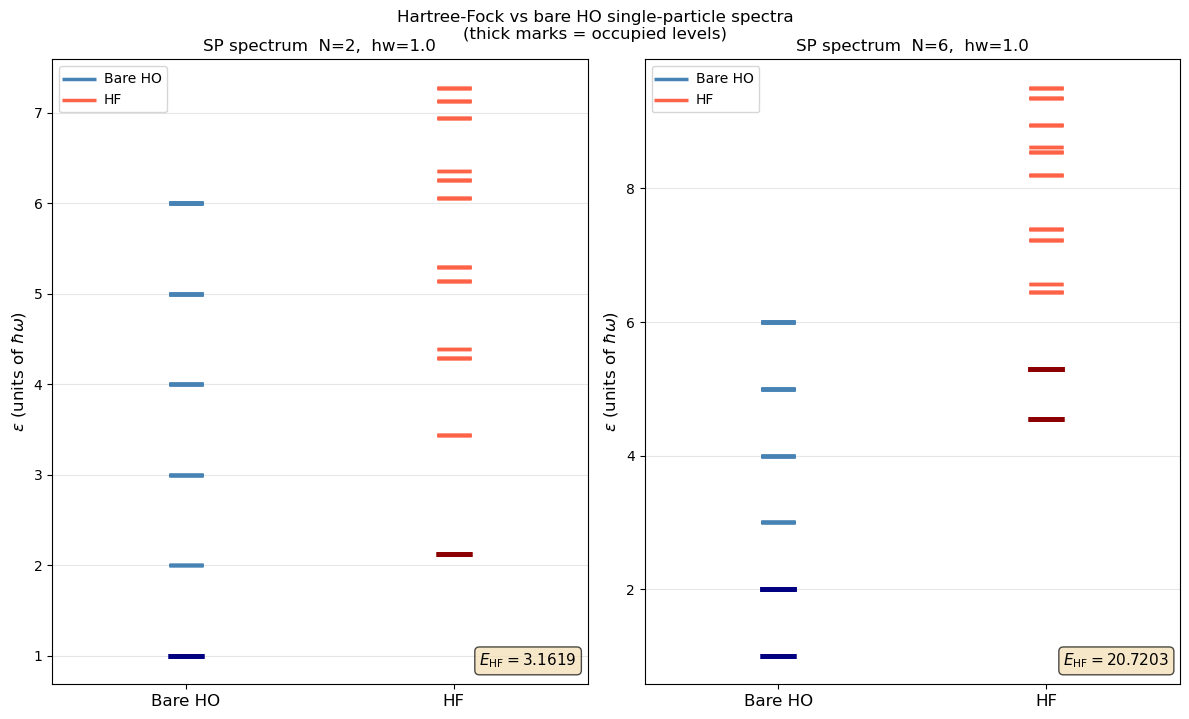

In [18]:
import matplotlib.pyplot as plt

hw = 1.0
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

for ax, N, E_HF, eps_HF in [
        (axes[0], 2,  E2, eps2),
        (axes[1], 6,  E6, eps6)]:

    basis_n = build_basis(42)

    # Non-interacting SP energies for the same basis
    eps0 = sorted(set(sp_energy(n, m, hw) for n, m, _ in basis_n))
    # Degeneracies (count spinful states per energy)
    eps0_all = [sp_energy(n, m, hw) for n, m, _ in basis_n]

    # Plot bare HO levels on the left
    x_ho  = [0.6] * len(eps0_all)
    ax.scatter(x_ho, eps0_all, marker='_', s=600, color='steelblue',
               linewidths=2.5, label='Bare HO', zorder=3)

    # Plot HF levels on the right
    x_hf = [1.4] * len(eps_HF)
    ax.scatter(x_hf, eps_HF[:42], marker='_', s=600, color='tomato',
               linewidths=2.5, label='HF', zorder=3)

    # Mark occupied levels
    ax.scatter([0.6]*N, eps0_all[:N], marker='_', s=700,
               color='navy', linewidths=3.5, zorder=4)
    ax.scatter([1.4]*N, eps_HF[:N], marker='_', s=700,
               color='darkred', linewidths=3.5, zorder=4)

    ax.set_xlim(0.2, 1.8)
    ax.set_xticks([0.6, 1.4])
    ax.set_xticklabels(['Bare HO', 'HF'], fontsize=12)
    ax.set_ylabel(r'$\varepsilon$ (units of $\hbar\omega$)', fontsize=12)
    ax.set_title(f'SP spectrum  N={N},  hw={hw}', fontsize=12)
    ax.legend(fontsize=10, loc='upper left')
    ax.grid(axis='y', alpha=0.3)

    # Annotate HF energy
    ax.text(0.98, 0.03,
            f'$E_\\mathrm{{HF}} = {E_HF:.4f}$',
            transform=ax.transAxes, ha='right', fontsize=11,
            bbox=dict(boxstyle='round', fc='wheat', alpha=0.7))

plt.tight_layout()
plt.suptitle(
    'Hartree-Fock vs bare HO single-particle spectra\n'
    '(thick marks = occupied levels)',
             fontsize=12, y=1.02)
plt.show()

### 7.11  Dependence on the oscillator frequency $\hbar\omega$

As $\omega$ increases the oscillator confines electrons more tightly,
increasing the kinetic energy but also the Coulomb repulsion.
Because kinetic energy scales as $\omega$ while Coulomb scales as
$\sqrt{\omega}$, the interaction energy becomes relatively less
important at large $\omega$ (the *weak-coupling* limit).

In [ ]:
import matplotlib.pyplot as plt

hw_values = [0.25, 0.5, 1.0, 2.0, 4.0]

E2_list, E6_list = [], []
E0_2_list, E0_6_list = [], []

for hw_t in hw_values:
    basis_t = build_basis(42)
    sp_t, v_t = precompute_spatial_integrals(basis_t, hw_t)

    E2_t, _, _, _, _ = hartree_fock(2, basis_t, hw_t, sp_t, v_t)
    E6_t, _, _, _, _ = hartree_fock(6, basis_t, hw_t, sp_t, v_t)

    E0_2_t = sum(sp_energy(basis_t[a][0], basis_t[a][1], hw_t) for a in range(2))
    E0_6_t = sum(sp_energy(basis_t[a][0], basis_t[a][1], hw_t) for a in range(6))

    E2_list .append(E2_t);   E0_2_list.append(E0_2_t)
    E6_list .append(E6_t);   E0_6_list.append(E0_6_t)
    print(f"  hw={hw_t:.2f}:  N=2 E_HF={E2_t:.5f}  N=6 E_HF={E6_t:.5f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, E_list, E0_list, N in [
        (axes[0], E2_list,  E0_2_list, 2),
        (axes[1], E6_list,  E0_6_list, 6)]:
    E_arr  = np.array(E_list)
    E0_arr = np.array(E0_list)
    hw_arr = np.array(hw_values)

    ax.plot(hw_arr, E_arr,        'o-', color='tomato',    lw=2, label='$E_\\mathrm{HF}$')
    ax.plot(hw_arr, E0_arr,       's--', color='steelblue', lw=2, label='$E_0$ (bare HO)')
    ax.plot(hw_arr, E_arr-E0_arr, '^:', color='darkorchid', lw=2, label='Interaction')

    ax.set_xlabel(r'$\hbar\omega$', fontsize=12)
    ax.set_ylabel('Energy', fontsize=12)
    ax.set_title(f'$N={N}$: HF energy vs $\\hbar\\omega$', fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()
print()
print("Interaction energy scales as sqrt(hw): relative importance decreases at large hw.")

  Precomputing spatial integrals: 21 spatial states, up to 194481 combinations ... done.  14703 non-zero  (12.6 s)


---
## 8  Exercises

### Analytical

1. **HF energy formula for $N=2$.**  
   For two electrons in the closed-shell state
   $|0,0,\uparrow;0,0,\downarrow\rangle$, derive the HF total energy
   $E_\mathrm{HF} = 2\hbar\omega + \langle 0,0;0,0|\hat{v}|0,0;0,0\rangle$
   from the general formula $E = \frac{1}{2}\mathrm{Tr}[(h_0+F)\rho]$.
   Why does the exchange term not contribute for opposite spins?

2. **Koopmans' theorem.**  
   Using the energy differences from the SCF results, estimate the
   ionisation energy of the $N=2$ quantum dot (energy to remove one
   electron from the closed shell) and compare with $-\varepsilon_0$.

3. **Fock matrix symmetry.**  
   Show that the Fock matrix $F$ is Hermitian, which guarantees that
   its eigenvalues are real and its eigenvectors form an orthonormal basis.

4. **Exchange cancellation.**  
   For $N=2$ with opposite spins, show explicitly that the exchange
   contribution to the Fock matrix between the two occupied orbitals
   is exactly zero.

### Computational

5. **Convergence with basis size.**  
   Extend the convergence study in Section 7.9 to $N=12$ and $N=20$.
   At what basis size does the energy converge to within $10^{-3}$
   of the 42-state result for each particle number?

6. **Shell-model analysis of the density matrix.**  
   For the converged $N=6$ solution, compute the occupation number
   of each HO shell: $n_{N_s} = \sum_{p \in N_s}\rho_{pp}$.
   How much does the self-consistent field mix the bare HO shells?

7. **Different oscillator frequencies.**  
   Run the HF calculation for $N=2$ at $\hbar\omega \in
   \{0.1, 0.25, 0.5, 1, 2, 5, 10\}$.
   Plot $E_\mathrm{interaction}/E_0$ vs $\hbar\omega$
   and verify that it scales as $\hbar\omega^{-1/2}$.

8. **$N=12$ and $N=20$ closed shells.**  
   Run the HF calculation for $N=12$ (shells $N_s=0,1,2$ full) and
   $N=20$ (shells $N_s=0,1,2,3$ full) using the 42-state basis.
   Tabulate $E_0$, $E_\mathrm{HF}$, and the interaction energy,
   and compare the pattern with the $N=2$ and $N=6$ results.

9. **Symmetry of the HF solution.**  
   For a closed-shell quantum dot the exact HF solution preserves
   the circular symmetry ($m$ is still a good quantum number).
   Verify this by showing that the converged coefficient matrix $C$
   does not mix states with different $m$.

10. **Beyond HF: first-order perturbation correction.**  
    The HF energy overestimates the interaction energy relative to
    the exact result because it neglects correlation.
    Compute the first-order Møller-Plesset (MP2) correction:
    $$
    E_\mathrm{MP2} = -\sum_{a<b}^{\mathrm{occ}}\sum_{r<s}^{\mathrm{virt}}
    \frac{|\langle ab\|\hat{v}\|rs\rangle|^2}
    {\varepsilon_r + \varepsilon_s - \varepsilon_a - \varepsilon_b}
    $$
    for the $N=2$ case using the HF eigenvalues from Section 7.7.